### Astrostatistic Lecture 4 

#### Part 1

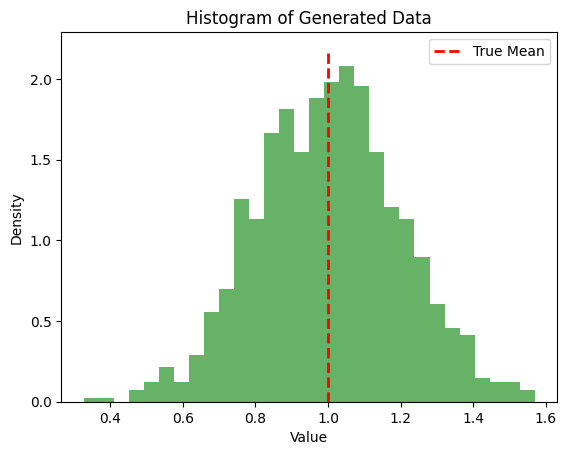

In [66]:
import numpy as np
import math 
import matplotlib.pyplot as plt
from scipy import stats 
from scipy.stats import norm

true_mean = 1
true_dev = 0.2
N = 1000
data = np.random.normal(true_mean, true_dev, N) #generating fake data from a gaussian distribution 

plt.hist(data, bins=30, density=True, alpha=0.6, color='g') #plotting the histogram of the data
plt.title('Histogram of Generated Data')
plt.vlines(true_mean, 0, plt.ylim()[1], color='r', linestyle='dashed', linewidth=2, label='True Mean') #plotting the true mean as a vertical line
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()


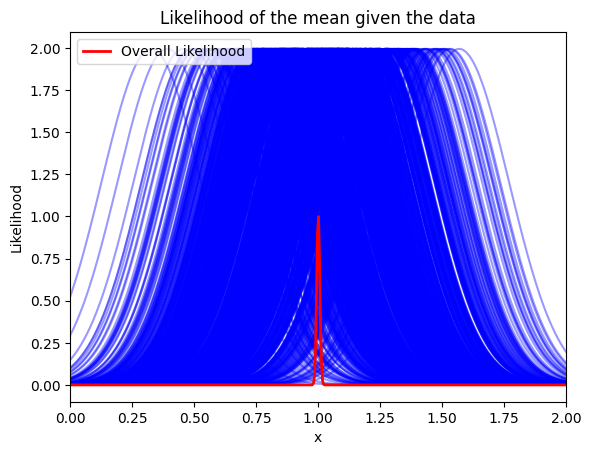

Estimated Mean: 1.0020020020020022
Difference between true mean and estimated mean: 0.002002002002002179


In [67]:
overall_array = None  
mu_grid = np.linspace(-1, 3, 1000)

for i, point in enumerate(data):
    likelihood = norm.pdf(point, loc=mu_grid, scale=true_dev) #calculating the likelihood for each point in the data
    plt.plot(mu_grid, likelihood, color='blue', alpha=0.4)
    if i == 0:
        overall_array = likelihood
    else:
        overall_array = overall_array * likelihood   #calculating the overall likelihood by multiplying the likelihoods of all the points in the data

# normalization of the overall likelihood
normalized_array = overall_array / np.max(overall_array)
plt.plot(mu_grid, normalized_array, color='red', linewidth=2, label='Overall Likelihood')
plt.legend()
plt.title('Likelihood of the mean given the data')
plt.xlabel("x")
plt.xlim(0, 2)
plt.ylabel("Likelihood")
plt.show()

estimated_mean = mu_grid[np.argmax(normalized_array)] #the estimated mean is the value of mu that maximizes the overall likelihood
print(f'Estimated Mean: {estimated_mean}')
print(f"Difference between true mean and estimated mean: {abs(true_mean - estimated_mean)}")

#### Part 2

In [68]:
#now we basically try to estimate the Fisher information matrix
log_likelihood = np.log(normalized_array) #find the log_likelihood
idx_max = np.argmax(log_likelihood) #find the point where is maximized
second_der = np.diff(log_likelihood, n=2) #calculate the second derivative
normalization = mu_grid[1] - mu_grid[0] #normalization from the grid
fisher_information = - second_der[idx_max-1] / normalization**2 #normalizing the second derivative
sigma = 1/np.sqrt(fisher_information) #the error on the estimated mean is the inverse of the square root of the Fisher information

print(f"Estimated error on the mean: {sigma}")
Real_sigma = true_dev / np.sqrt(N) #real error 
print(f"\nReal error on the mean: {Real_sigma}")
difference = abs(sigma - Real_sigma) #difference between the estimated error and the real error
print(f"\nDifference between estimated error and real error: {difference}")

Estimated error on the mean: 0.006324555320336965

Real error on the mean: 0.006324555320336759

Difference between estimated error and real error: 2.0643209364124004e-16


/tmp/ipykernel_9830/3120011961.py:2: RuntimeWarning: divide by zero encountered in log
  log_likelihood = np.log(normalized_array) #find the log_likelihood


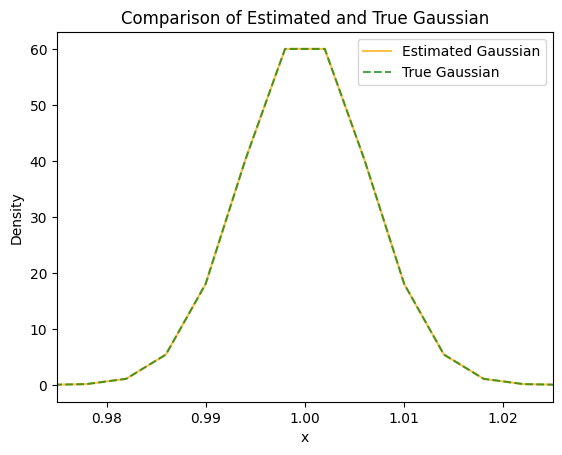

In [75]:
#now we plot a gaussia with true mean and estimated error and see if it matches the real one 
x = np.linspace(-1, 3, 1000)
estimated_gaussian = norm.pdf(x, loc=true_mean, scale=sigma)
true_gaussian = norm.pdf(x, loc=true_mean, scale=Real_sigma)
plt.plot(x, estimated_gaussian, color='orange', label='Estimated Gaussian', alpha=0.7)
plt.plot(x, true_gaussian, color='green', label='True Gaussian', linestyle='dashed', alpha=0.7)
plt.title('Comparison of Estimated and True Gaussian')
plt.xlabel('x')
plt.xlim(0.975, 1.025)
plt.ylabel('Density')
plt.legend()
plt.show()

#### Part 3

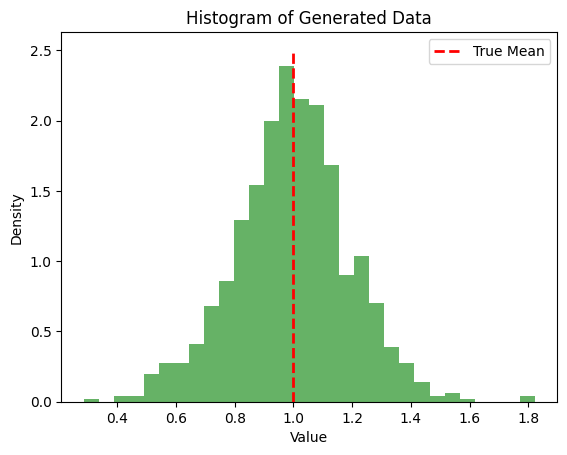

In [70]:
#now basically the same thing but with different sigmas (variables now have pedix 2 so the notebook doesn't get confused)
true_mean_2 = 1
N = 1000
true_dev_2 = np.zeros(N)
data_2 = np.zeros(N)
for i in range(N):
    true_dev_2[i] = np.random.normal(0.2, 0.05) #generating a random standard deviation for each point in the data
    data_2[i] = np.random.normal(true_mean_2, true_dev_2[i]) 

plt.hist(data_2, bins=30, density=True, alpha=0.6, color='g')
plt.title('Histogram of Generated Data')
plt.vlines(true_mean_2, 0, plt.ylim()[1], color='r', linestyle='dashed', linewidth=2, label='True Mean') 
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

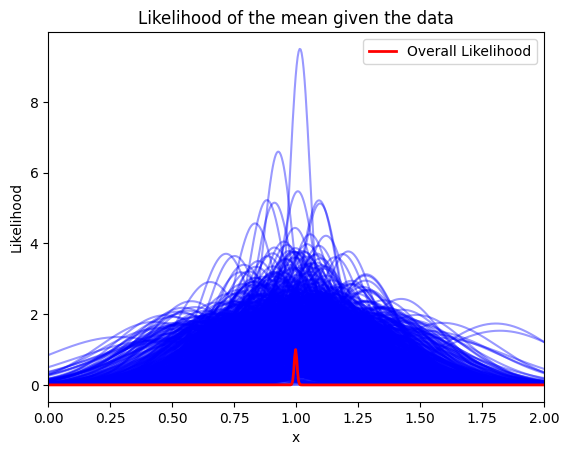

Estimated Mean: 0.997997997997998
Weighted True Mean: 0.9978545754089055
Difference between true mean and estimated mean: 0.00014342258909250116


In [71]:
#literally a ctrl+c, ctrl+v of the previous one
overall_array_2 = None  
mu_grid_2 = np.linspace(-1, 3, 1000)

for i, point in enumerate(data_2):
    likelihood_2 = norm.pdf(point, loc=mu_grid_2, scale=true_dev_2[i]) #just put the different deviations
    plt.plot(mu_grid_2, likelihood_2, color='blue', alpha=0.4)
    if i == 0:
        overall_array_2 = likelihood_2
    else:
        overall_array_2 = overall_array_2 * likelihood_2    


normalized_array_2 = overall_array_2 / np.max(overall_array_2)
plt.plot(mu_grid_2, normalized_array_2, color='red', linewidth=2, label='Overall Likelihood')
plt.legend()
plt.title('Likelihood of the mean given the data')
plt.xlabel("x")
plt.xlim(0, 2)
plt.ylabel("Likelihood")
plt.show()

estimated_mean_2 = mu_grid_2[np.argmax(normalized_array_2)] 
weighted_true_mean = np.sum(data_2 / true_dev_2**2) / np.sum(1 / true_dev_2**2) #calculate the weighted mean of the data
print(f'Estimated Mean: {estimated_mean_2}')
print(f'Weighted True Mean: {weighted_true_mean}')
print(f"Difference between true mean and estimated mean: {abs(weighted_true_mean - estimated_mean_2)}")

In [72]:
log_likelihood_2 = np.log(normalized_array_2) 
idx_max_2 = np.argmax(log_likelihood_2) 
second_der_2 = np.diff(log_likelihood_2, n=2) 
normalization_2 = mu_grid_2[1] - mu_grid_2[0] 
fisher_information_2 = - second_der_2[idx_max_2-1] / normalization_2**2 
sigma_2 = 1/np.sqrt(fisher_information_2) 

print(f"Estimated error on the mean: {sigma_2}")
Real_sigma_2 = 1 / np.sqrt(np.sum(1 / true_dev_2**2))  #real error for the case with different deviations
print(f"\nReal error on the mean: {Real_sigma_2}")
difference_2 = abs(sigma_2 - Real_sigma_2) 
print(f"\nDifference between estimated error and real error: {difference_2}")

Estimated error on the mean: 0.005665739173190673

Real error on the mean: 0.0056657391731908795

Difference between estimated error and real error: 2.0643209364124004e-16


/tmp/ipykernel_9830/1489401481.py:1: RuntimeWarning: divide by zero encountered in log
  log_likelihood_2 = np.log(normalized_array_2)


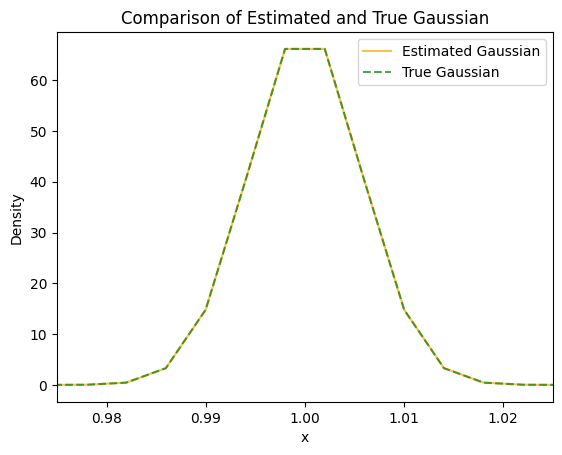

In [74]:
#final plot of the gaussians
x_2 = np.linspace(-1, 3, 1000)
estimated_gaussian_2 = norm.pdf(x_2, loc=true_mean_2, scale=sigma_2)
true_gaussian_2 = norm.pdf(x_2, loc=true_mean_2, scale=Real_sigma_2)
plt.plot(x_2, estimated_gaussian_2, color='orange', label='Estimated Gaussian', alpha=0.7)
plt.plot(x_2, true_gaussian_2, color='green', label='True Gaussian', linestyle='dashed', alpha=0.7)
plt.title('Comparison of Estimated and True Gaussian')
plt.xlabel('x')
plt.xlim(0.975, 1.025)
plt.ylabel('Density')
plt.legend()
plt.show()